# 머신러닝 대표 모델 심플 실습


# 0. 라이브러리 설치 및 불러오기

In [1]:
!pip -q install xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.4 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)

RANDOM_STATE = 42
print("라이브러리 준비 완료")

라이브러리 준비 완료


# 1. 머신러닝 기본 흐름

모든 모델은 기본적으로 다음 순서로 사용합니다.

```python
model = 모델()
model.fit(X_train, y_train)      # 학습
pred = model.predict(X_test)     # 예측
score = 평가함수(y_test, pred)   # 평가
```

아래 그림은 지도학습의 전체 흐름을 나타냅니다.

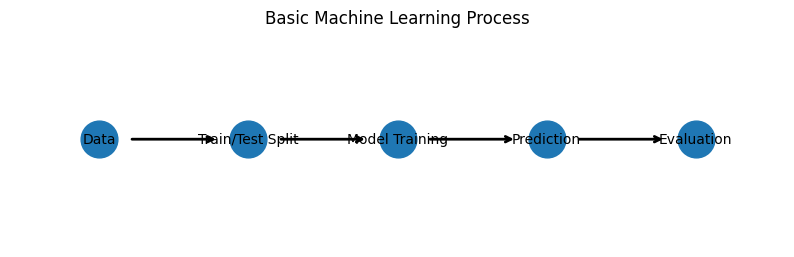

In [3]:
plt.figure(figsize=(10, 2.8))
steps = ["Data", "Train/Test Split", "Model Training", "Prediction", "Evaluation"]
x = np.arange(len(steps))

plt.scatter(x, np.zeros(len(x)), s=700)
for i, step in enumerate(steps):
    plt.text(i, 0, step, ha="center", va="center", fontsize=10)
    if i < len(steps) - 1:
        plt.annotate("", xy=(i + 0.8, 0), xytext=(i + 0.2, 0),
                     arrowprops=dict(arrowstyle="->", lw=2))
plt.xlim(-0.6, len(steps)-0.4)
plt.ylim(-0.5, 0.5)
plt.axis("off")
plt.title("Basic Machine Learning Process")
plt.show()

# 2. 지도학습－분류 모델

분류는 데이터를 미리 정해진 범주 중 하나로 나누는 문제입니다.

이번 실습에서는 붓꽃의 꽃잎과 꽃받침 길이를 이용해 다음 세 품종을 분류합니다.

- Setosa
- Versicolor
- Virginica

In [4]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

print("입력 데이터 크기:", X.shape)
print("정답 데이터 크기:", y.shape)
print("특성 이름:", iris.feature_names)
print("범주 이름:", iris.target_names)

iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df["target"] = y
display(iris_df.head())

입력 데이터 크기: (150, 4)
정답 데이터 크기: (150,)
특성 이름: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
범주 이름: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y
)

print("학습 데이터:", X_train.shape)
print("평가 데이터:", X_test.shape)

학습 데이터: (105, 4)
평가 데이터: (45, 4)


## 2-1. 분류 모델 개념 그림

아래 그림은 모델이 데이터를 서로 다른 범주로 나누는 모습을 단순화한 것입니다.

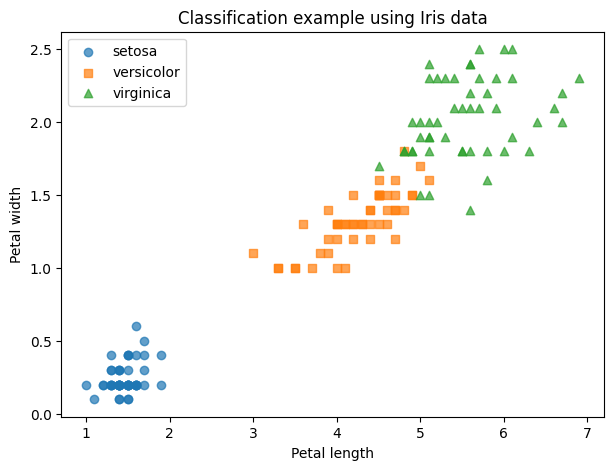

In [6]:
plt.figure(figsize=(7, 5))

for class_id, marker in zip([0, 1, 2], ["o", "s", "^"]):
    mask = y == class_id
    plt.scatter(
        X[mask, 2],
        X[mask, 3],
        marker=marker,
        label=iris.target_names[class_id],
        alpha=0.7
    )

plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.title("Classification example using Iris data")
plt.legend()
plt.show()

## 2-2. 분류 모델 설명

### 로지스틱 회귀
입력값을 이용해 각 범주에 속할 확률을 계산하고 가장 가능성이 높은 범주로 분류하는 기본 모델입니다.

### 의사결정나무
특성값에 대해 `예/아니오` 형태의 조건을 반복해서 적용하여 최종 범주를 판단합니다.

### 랜덤 포레스트
여러 개의 의사결정나무를 학습한 뒤 다수결로 최종 범주를 결정합니다.

### 서포트 벡터 머신
서로 다른 범주의 데이터를 가장 잘 구분하는 경계선을 찾습니다.

### k-최근접 이웃
새로운 데이터와 가장 가까운 주변 데이터의 범주를 참고하여 분류합니다.

### 나이브 베이즈
각 특성이 범주에 속할 확률을 계산하여 가장 가능성이 높은 범주를 선택합니다.

### Gradient Boosting
이전 의사결정나무가 틀린 데이터를 다음 나무가 보완하도록 순차적으로 학습합니다.

### AdaBoost
잘못 분류된 데이터에 더 큰 가중치를 주면서 여러 약한 모델을 순차적으로 학습합니다.

### Extra Trees
랜덤 포레스트보다 더 무작위로 조건을 선택하여 여러 의사결정나무를 구성합니다.

### XGBoost
오차를 순차적으로 보완하면서 정규화와 최적화 기법을 적용한 고성능 부스팅 모델입니다.

### LightGBM
리프 중심으로 트리를 성장시켜 대규모 데이터를 빠르게 학습하는 부스팅 모델입니다.

### CatBoost
범주형 변수를 효과적으로 처리하도록 설계된 부스팅 모델입니다.

### HistGradientBoosting
연속형 값을 구간으로 나눈 히스토그램을 이용해 빠르게 학습하는 부스팅 모델입니다.

## 2-3. 분류 모델별 학습·예측·평가

아래 코드는 모델을 딕셔너리에 저장한 뒤 동일한 데이터로 한 번에 비교합니다.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=3, random_state=RANDOM_STATE
    ),
    "SVM": SVC(),
    "k-NN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE
    ),
    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
        n_estimators=50,
        learning_rate=1.0,
        random_state=RANDOM_STATE
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=100, max_depth=3, random_state=RANDOM_STATE
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=RANDOM_STATE,
        eval_metric="mlogloss"
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=RANDOM_STATE,
        verbosity=-1
    ),
    "CatBoost": cb.CatBoostClassifier(
        iterations=100,
        learning_rate=0.1,
        depth=3,
        random_seed=RANDOM_STATE,
        verbose=0
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}

print("분류 모델 수:", len(classifiers))

분류 모델 수: 13


In [8]:
classification_results = []
trained_classifiers = {}

for name, clf in classifiers.items():
    # 1. 학습
    clf.fit(X_train, y_train)

    # 2. 예측
    pred = clf.predict(X_test)

    # 3. 평가
    train_accuracy = clf.score(X_train, y_train)
    test_accuracy = accuracy_score(y_test, pred)

    cross_val_scores = cross_val_score(clf, X, y, cv=5)

    classification_results.append({
        "Algorithm": name,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Cross-Validation Mean": cross_val_scores.mean(),
        "Cross-Validation Std": cross_val_scores.std()
    })

    trained_classifiers[name] = clf

classification_results_df = pd.DataFrame(classification_results)
classification_results_df = classification_results_df.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

display(classification_results_df.round(4))

,Algorithm,Train Accuracy,Test Accuracy,Cross-Validation Mean,Cross-Validation Std
0,Decision Tree,0.9810,0.9778,0.9733,0.0249
1,k-NN,0.9714,0.9778,0.9733,0.0249
2,SVM,0.9714,0.9556,0.9667,0.0211
3,Logistic Regression,0.9714,0.9333,0.9733,0.0249
4,Gradient Boosting,1.0000,0.9333,0.9600,0.0327
5,XGBoost,1.0000,0.9333,0.9467,0.0267
6,AdaBoost,1.0000,0.9333,0.9533,0.0340
7,Random Forest,0.9714,0.9111,0.9667,0.0211
8,Naive Bayes,0.9810,0.9111,0.9533,0.0267
9,Extra Trees,0.9810,0.9111,0.9600,0.0249


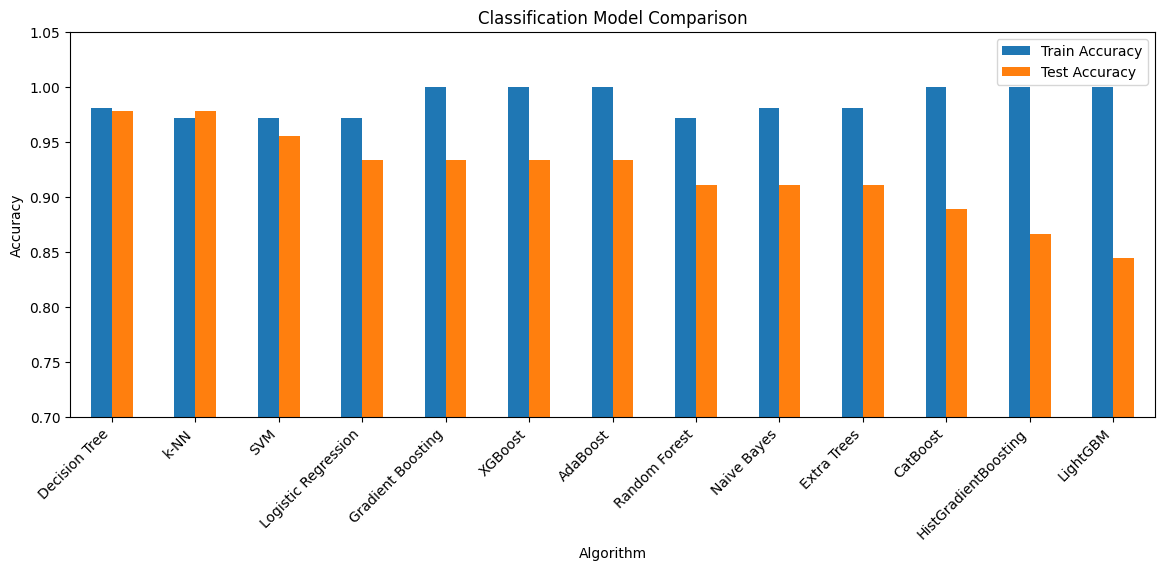

In [9]:
classification_results_df.set_index("Algorithm")[["Train Accuracy", "Test Accuracy"]].plot(
    kind="bar",
    figsize=(14, 5)
)
plt.ylim(0.7, 1.05)
plt.ylabel("Accuracy")
plt.title("Classification Model Comparison")
plt.xticks(rotation=45, ha="right")
plt.show()

## 2-4. 특정 분류 모델의 예측 결과 확인

In [10]:
selected_model_name = "Random Forest"
selected_model = trained_classifiers[selected_model_name]

pred = selected_model.predict(X_test)

print("선택한 모델:", selected_model_name)
print("실제 정답:", y_test[:10])
print("예측 결과:", pred[:10])
print("정확도:", accuracy_score(y_test, pred))

선택한 모델: Random Forest
실제 정답: [2 1 2 1 2 2 1 1 0 2]
예측 결과: [2 1 1 1 2 2 1 1 0 2]
정확도: 0.9111111111111111


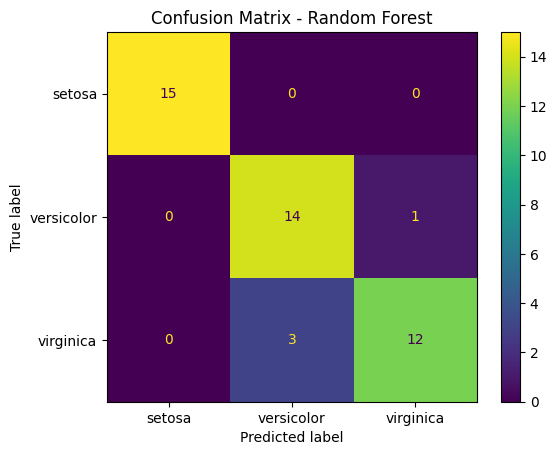

In [11]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    display_labels=iris.target_names
)
plt.title(f"Confusion Matrix - {selected_model_name}")
plt.show()

# 3. 지도학습－회귀 모델

회귀는 연속적인 숫자 값을 예측하는 문제입니다.

이번 실습에서는 당뇨병 환자의 측정값을 이용해 질병 진행 정도를 예측합니다.

In [12]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

X_reg = diabetes.data
y_reg = diabetes.target

print("입력 데이터 크기:", X_reg.shape)
print("정답 데이터 크기:", y_reg.shape)

입력 데이터 크기: (442, 10)
정답 데이터 크기: (442,)


In [13]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg,
    test_size=0.3,
    random_state=RANDOM_STATE
)

print("학습 데이터:", X_train_reg.shape)
print("평가 데이터:", X_test_reg.shape)

학습 데이터: (309, 10)
평가 데이터: (133, 10)


## 3-1. 회귀 모델 개념 그림

회귀 모델은 입력값과 결과값 사이의 관계를 찾아 연속적인 값을 예측합니다.

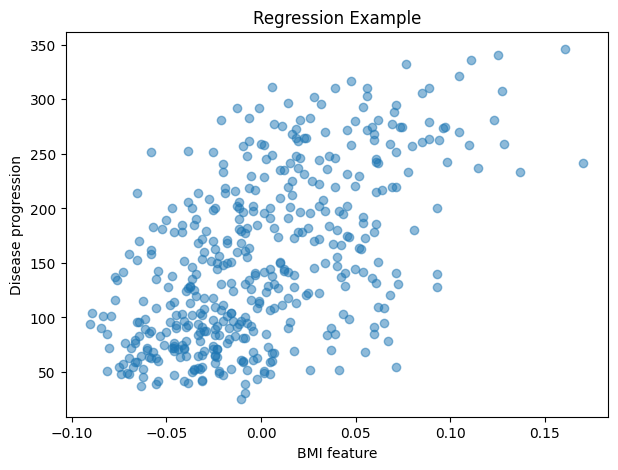

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(X_reg[:, 2], y_reg, alpha=0.5)
plt.xlabel("BMI feature")
plt.ylabel("Disease progression")
plt.title("Regression Example")
plt.show()

## 3-2. 회귀 모델 설명

### 선형 회귀
입력 변수와 결과값 사이의 관계를 직선 형태로 학습하는 기본 회귀 모델입니다.

### 다항 회귀
입력 변수의 제곱항이나 세제곱항을 추가하여 곡선 형태의 관계를 학습합니다.

### 릿지 회귀
회귀계수가 지나치게 커지지 않도록 L2 규제를 적용해 과대적합을 줄입니다.

### 라쏘 회귀
L1 규제를 적용해 중요하지 않은 변수의 회귀계수를 0으로 만들 수 있습니다.

### 엘라스틱넷
릿지와 라쏘의 규제를 함께 사용하는 회귀 모델입니다.

### 의사결정나무 회귀
데이터를 여러 조건으로 나눈 뒤 각 구간의 평균값으로 결과를 예측합니다.

### 랜덤 포레스트 회귀
여러 의사결정나무의 예측값을 평균하여 최종 결과를 계산합니다.

### 서포트 벡터 회귀
일정한 오차 범위 안에서 데이터를 가장 잘 설명하는 회귀선을 찾습니다.

### Gradient Boosting 회귀
이전 트리의 예측 오차를 다음 트리가 순차적으로 보완합니다.

### Extra Trees 회귀
조건을 무작위로 선택한 여러 의사결정나무의 결과를 평균합니다.

### XGBoost 회귀
이전 모델의 오차를 보완하면서 최적화된 방식으로 트리를 순차 학습합니다.

### LightGBM 회귀
히스토그램과 리프 중심 트리 성장을 이용해 빠르게 학습합니다.

### CatBoost 회귀
범주형 데이터 처리에 강점이 있는 부스팅 회귀 모델입니다.

### HistGradientBoosting 회귀
값을 여러 구간으로 나눈 히스토그램을 이용해 빠르게 부스팅을 수행합니다.

## 3-3. 회귀 모델별 학습·예측·평가

In [15]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.svm import SVR

# 다항 회귀만 제곱항을 별도로 생성
poly = PolynomialFeatures(degree=2, include_bias=False)
X_reg_poly = poly.fit_transform(X_reg)

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_reg_poly, y_reg,
    test_size=0.3,
    random_state=RANDOM_STATE
)

In [28]:
regressors = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1, max_iter=10000),
    "Decision Tree Regressor": DecisionTreeRegressor(
        max_depth=4, random_state=RANDOM_STATE
    ),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100, max_depth=5, random_state=RANDOM_STATE
    ),
    "SVR": SVR(),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        n_estimators=100, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE
    ),
    "AdaBoost Regressor": AdaBoostRegressor(
        n_estimators=100, learning_rate=0.05, random_state=RANDOM_STATE
    ),
    "Extra Trees Regressor": ExtraTreesRegressor(
        n_estimators=100, max_depth=5, random_state=RANDOM_STATE
    ),
    "XGBoost Regressor": xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE,
        objective="reg:squarederror"
    ),
    "LightGBM Regressor": lgb.LGBMRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE,
        verbosity=-1
    ),
    "CatBoost Regressor": cb.CatBoostRegressor(
        iterations=100,
        learning_rate=0.05,
        depth=3,
        random_seed=RANDOM_STATE,
        verbose=0
    ),
    "HistGradientBoosting Regressor": HistGradientBoostingRegressor(
        max_iter=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}

print("회귀 모델 수:", len(regressors))

회귀 모델 수: 13


In [29]:
regression_results = []
trained_regressors = {}

for name, reg in regressors.items():
    # 1. 학습
    reg.fit(X_train_reg, y_train_reg)

    # 2. 예측
    pred = reg.predict(X_test_reg)

    # 3. 평가
    mae = mean_absolute_error(y_test_reg, pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, pred))
    r2 = r2_score(y_test_reg, pred)

    cv_scores = cross_val_score(
        reg,
        X_reg,
        y_reg,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )

    regression_results.append({
        "Algorithm": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Cross-Validation RMSE Mean": -cv_scores.mean(),
        "Cross-Validation RMSE Std": cv_scores.std()
    })

    trained_regressors[name] = reg

# 다항 회귀는 변환된 데이터로 별도 학습
poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train_poly)
poly_pred = poly_reg.predict(X_test_poly)

poly_cv_scores = cross_val_score(
    LinearRegression(),
    X_reg_poly,
    y_reg,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

regression_results.append({
    "Algorithm": "Polynomial Regression",
    "MAE": mean_absolute_error(y_test_poly, poly_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test_poly, poly_pred)),
    "R2": r2_score(y_test_poly, poly_pred),
    "Cross-Validation RMSE Mean": -poly_cv_scores.mean(),
    "Cross-Validation RMSE Std": poly_cv_scores.std()
})

trained_regressors["Polynomial Regression"] = poly_reg

regression_results_df = pd.DataFrame(regression_results)
regression_results_df = regression_results_df.sort_values(
    by="RMSE"
).reset_index(drop=True)

display(regression_results_df.round(4))

,Algorithm,MAE,RMSE,R2,Cross-Validation RMSE Mean,Cross-Validation RMSE Std
0,CatBoost Regressor,40.7190,50.8272,0.5214,55.3852,1.1063
1,AdaBoost Regressor,41.5485,51.4847,0.5090,57.2642,1.6547
2,LightGBM Regressor,40.8669,51.6054,0.5067,56.8464,1.6076
3,HistGradientBoosting Regressor,41.3189,51.7455,0.5040,57.1433,1.4098
4,Extra Trees Regressor,42.7678,52.0500,0.4981,55.7719,1.3487
5,Random Forest Regressor,42.1809,52.6204,0.4871,57.3735,2.1657
6,Lasso Regression,41.9386,52.6798,0.4859,54.8430,1.0690
7,XGBoost Regressor,42.8121,53.1111,0.4775,57.2180,1.7185
8,Linear Regression,41.9194,53.1202,0.4773,54.6918,1.3745
9,Gradient Boosting Regressor,43.2989,53.8732,0.4624,57.6576,2.1234


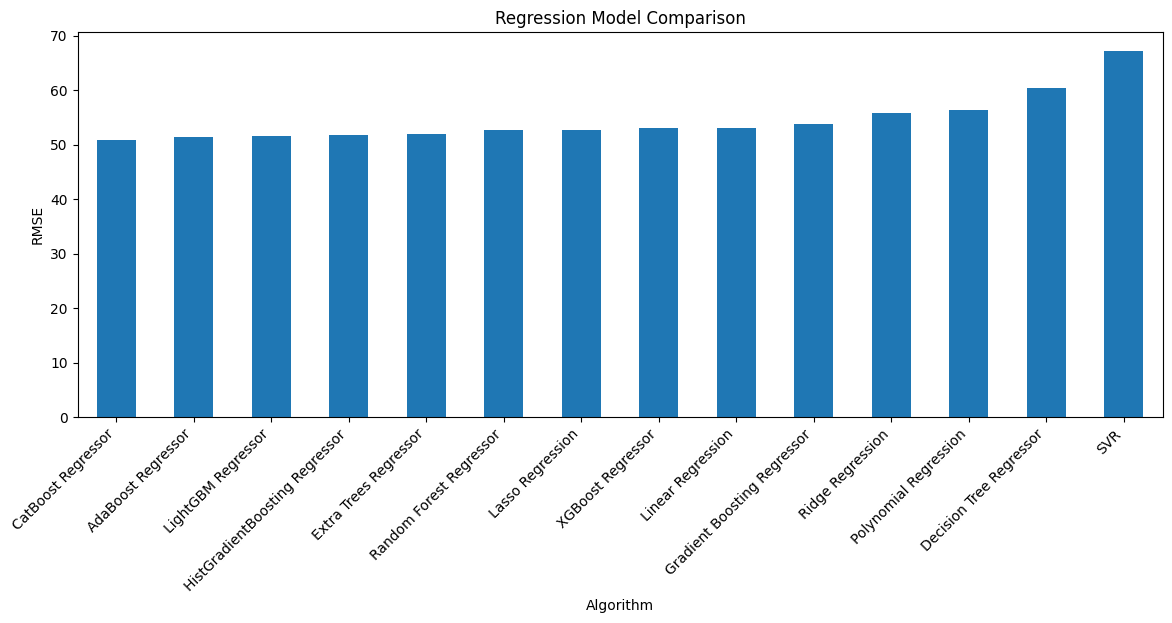

In [30]:
regression_results_df.set_index("Algorithm")["RMSE"].plot(
    kind="bar",
    figsize=(14, 5)
)
plt.ylabel("RMSE")
plt.title("Regression Model Comparison")
plt.xticks(rotation=45, ha="right")
plt.show()

## 3-4. 특정 회귀 모델의 실제값과 예측값 비교

In [19]:
selected_regressor_name = "Random Forest Regressor"
selected_regressor = trained_regressors[selected_regressor_name]

reg_pred = selected_regressor.predict(X_test_reg)

print("선택한 모델:", selected_regressor_name)
print("실제값:", y_test_reg[:10])
print("예측값:", np.round(reg_pred[:10], 2))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, reg_pred)))

선택한 모델: Random Forest Regressor
실제값: [219.  70. 202. 230. 111.  84. 242. 272.  94.  96.]
예측값: [160.3  176.97 142.26 248.5  114.01 119.71 249.82 212.23 134.01 171.91]
RMSE: 52.620377257429695


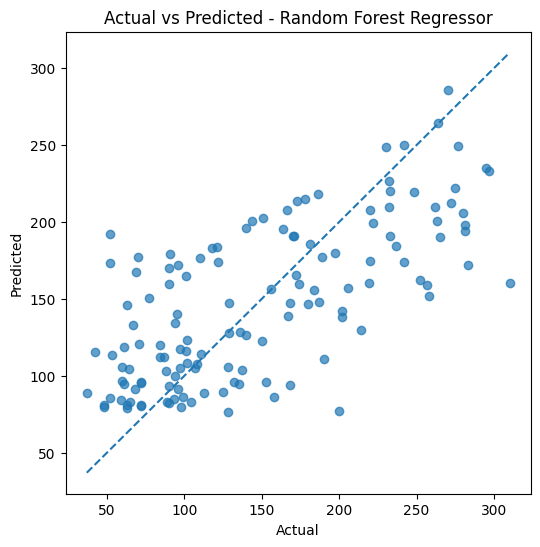

In [20]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, reg_pred, alpha=0.7)

min_value = min(y_test_reg.min(), reg_pred.min())
max_value = max(y_test_reg.max(), reg_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted - {selected_regressor_name}")
plt.show()

# 4. 비지도학습－K-Means 군집화

K-Means는 정답 없이 서로 비슷한 데이터를 K개의 그룹으로 묶는 모델입니다.

### 동작 과정

1. K개의 중심점을 설정
2. 각 데이터를 가장 가까운 중심점에 배정
3. 각 군집의 평균 위치로 중심점을 이동
4. 중심점이 거의 변하지 않을 때까지 반복

In [21]:
from sklearn.cluster import KMeans

X_cluster = iris.data[:, [2, 3]]

kmeans = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=10
)

# 학습과 동시에 군집 번호 예측
cluster_labels = kmeans.fit_predict(X_cluster)

print("군집 번호:", cluster_labels[:20])
print("군집 중심점:")
print(kmeans.cluster_centers_)

군집 번호: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
군집 중심점:
[[5.59583333 2.0375    ]
 [1.462      0.246     ]
 [4.26923077 1.34230769]]


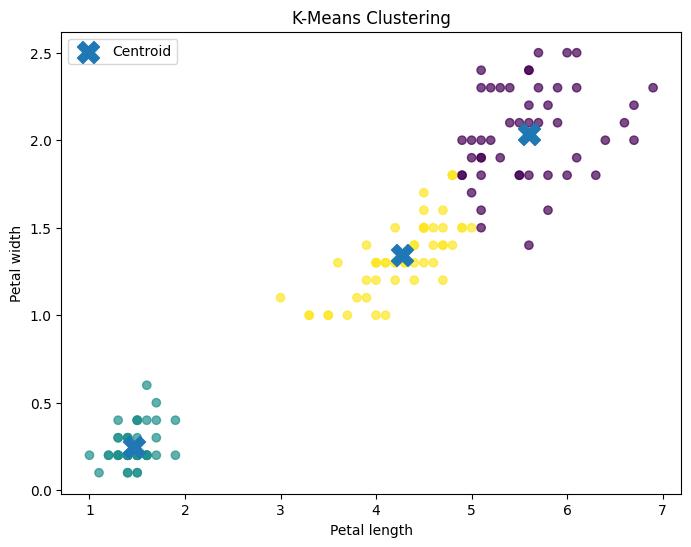

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_cluster[:, 0],
    X_cluster[:, 1],
    c=cluster_labels,
    alpha=0.7
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=250,
    label="Centroid"
)

plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.title("K-Means Clustering")
plt.legend()
plt.show()

## K-Means 평가

Silhouette Score는 같은 군집의 데이터는 가깝고 다른 군집의 데이터는 멀수록 높아집니다.

- 1에 가까울수록 군집이 잘 분리됨
- 0에 가까우면 군집이 서로 겹침
- 음수이면 일부 데이터가 잘못된 군집에 배정되었을 가능성이 있음

In [23]:
silhouette = silhouette_score(X_cluster, cluster_labels)

print("Silhouette Score:", round(silhouette, 4))

Silhouette Score: 0.6605


# 5. 비지도학습－Isolation Forest 이상탐지

Isolation Forest는 다른 데이터와 멀리 떨어져 있거나 드물게 나타나는 데이터를 이상치로 탐지합니다.

### 핵심 원리

- 정상 데이터는 주변에 비슷한 데이터가 많아 분리하기 어렵습니다.
- 이상 데이터는 주변과 멀리 떨어져 있어 적은 분할만으로 빠르게 고립됩니다.
- 빠르게 고립되는 데이터를 이상치로 판단합니다.

In [24]:
from sklearn.datasets import make_blobs
from sklearn.ensemble import IsolationForest

normal_data, _ = make_blobs(
    n_samples=300,
    centers=[[0, 0]],
    cluster_std=1.0,
    random_state=RANDOM_STATE
)

rng = np.random.RandomState(RANDOM_STATE)
outlier_data = rng.uniform(low=-6, high=6, size=(20, 2))

X_anomaly = np.vstack([normal_data, outlier_data])

print("전체 데이터 수:", len(X_anomaly))

전체 데이터 수: 320


In [25]:
isolation_forest = IsolationForest(
    n_estimators=100,
    contamination=0.06,
    random_state=RANDOM_STATE
)

# 학습과 동시에 예측
anomaly_pred = isolation_forest.fit_predict(X_anomaly)

# 1 = 정상, -1 = 이상
print("예측 결과 예시:", anomaly_pred[:20])

예측 결과 예시: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


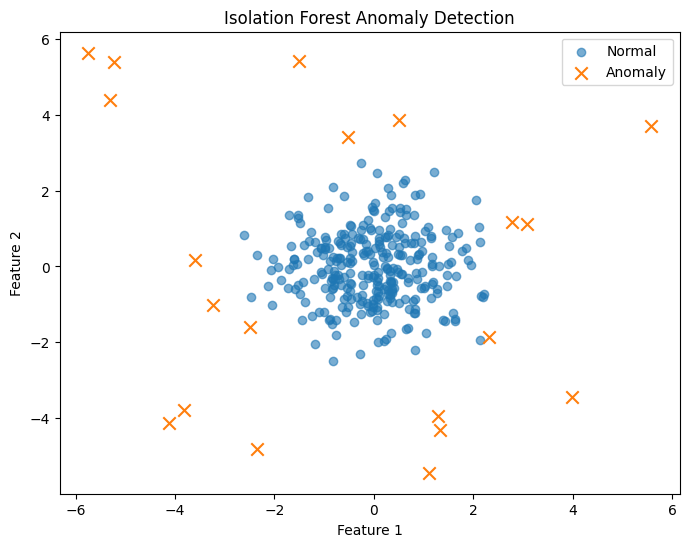

In [26]:
normal_mask = anomaly_pred == 1
anomaly_mask = anomaly_pred == -1

plt.figure(figsize=(8, 6))

plt.scatter(
    X_anomaly[normal_mask, 0],
    X_anomaly[normal_mask, 1],
    label="Normal",
    alpha=0.6
)

plt.scatter(
    X_anomaly[anomaly_mask, 0],
    X_anomaly[anomaly_mask, 1],
    label="Anomaly",
    marker="x",
    s=80
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Isolation Forest Anomaly Detection")
plt.legend()
plt.show()

In [27]:
normal_count = np.sum(anomaly_pred == 1)
anomaly_count = np.sum(anomaly_pred == -1)

print("정상으로 탐지된 데이터:", normal_count)
print("이상으로 탐지된 데이터:", anomaly_count)

정상으로 탐지된 데이터: 300
이상으로 탐지된 데이터: 20


# 6. 전체 정리

| 구분 | 목적 | 대표 모델 | 주요 평가 방법 |
|---|---|---|---|
| 분류 | 범주 예측 | Logistic Regression, Decision Tree, Random Forest, SVM, Boosting | Accuracy, Precision, Recall, F1 |
| 회귀 | 연속적인 수치 예측 | Linear Regression, Ridge, Random Forest Regressor, Boosting Regressor | MAE, RMSE, R² |
| 군집화 | 비슷한 데이터 그룹화 | K-Means | Silhouette Score |
| 이상탐지 | 정상 패턴에서 벗어난 데이터 탐지 | Isolation Forest | 탐지 개수, 시각화, 정답이 있으면 분류 지표 |

## 핵심 코드 패턴

### 지도학습

```python
model.fit(X_train, y_train)
pred = model.predict(X_test)
score = 평가함수(y_test, pred)
```

### 비지도학습

```python
labels = model.fit_predict(X)
```